Hello, below is a full tutorial for the tess-ice-giants repo for Phan, Rice, & Cassese 2026. 

In [11]:
# base imports
import numpy as np
import glob 

root = '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/'

## intitialize the list of sectors 
planet_sectors = ["u42", "u43", "u44", "n42", "n70"]

In [6]:
# orbit and detrend processing (~2mins)
from orbit_correction import correct_and_save_light_curves

## here we pull light curves from the tess_solarsystem_planets pipeline
raw_light_curves = f"{root}raw_light_curves/"

uranus_id = '799'  
neptune_id = '899'         
observer_id = '@tess'  

target_id_arr = [uranus_id, uranus_id, uranus_id, neptune_id, neptune_id]
observer_id_arr = [observer_id]*5

# uranus first, then neptune
ur_raw_lcs = sorted(glob.glob(raw_light_curves + '*Uranus*.txt'))
nep_raw_lcs = sorted(glob.glob(raw_light_curves + '*Neptune*.txt'))
data_file_arr = ur_raw_lcs + nep_raw_lcs
print(data_file_arr)

correct_and_save_light_curves(
    target_id_arr, 
    observer_id_arr, 
    data_file_arr, 
    root + 'light_curves/', 
    name_arr = [f"{sector}_lcs" for sector in planet_sectors],
    crop_range_arr = [[1400, 1600], [], [], [975, 1040], []]
)   

['/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/raw_light_curves/lc_Uranus_s42_cam4_ccd2.txt', '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/raw_light_curves/lc_Uranus_s43_cam2_ccd1.txt', '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/raw_light_curves/lc_Uranus_s44_cam1_ccd4.txt', '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/raw_light_curves/lc_Neptune_s42_cam2_ccd4.txt', '/home/ktp9/TESSNeptune24/tess-ice-giants/final_data/raw_light_curves/lc_Neptune_s70_cam1_ccd1.txt']
Parsing Light Curve
Getting ephemeris
Correcting Light curve
Parsing Light Curve
Getting ephemeris
Correcting Light curve
Parsing Light Curve
Getting ephemeris
Correcting Light curve
Parsing Light Curve
Getting ephemeris
Correcting Light curve
Parsing Light Curve
Getting ephemeris
Correcting Light curve


In [7]:
# load in the light curves
lc_dir = root + "light_curves/"
lc_list = []
for sector in planet_sectors:
    lc_list.append(np.load(lc_dir + f"{sector}_lcs.npz"))

###! Neptune's Sector 70 has a different cadence than the rest. !###
###! For uniformity, we  group s70 to the same cadence as the others. !###
from fullsector import group_and_average

#resample n70 to n42 time points
n70_times = group_and_average(lc_list[4]['time'], lc_list[3]['time'])
n70_corrections = group_and_average(lc_list[4]['orbit_corrected'], lc_list[3]['time'])
n70_detrended = group_and_average(lc_list[4]['detrended'], lc_list[3]['time'])

lc_list[4] = {'time': n70_times, 'orbit_corrected': n70_corrections, 'detrended': n70_detrended}

0.0 data points discarded
0.0 data points discarded
0.0 data points discarded


In [8]:
# now, lets find the peak frequencies (~30m)
from fullsector import save_periodograms

# make and save the periodograms
periodogram_dir = root + "periodograms/"
save_periodograms(lc_list, [f"{sector}" for sector in planet_sectors], periodogram_dir)


5it [11:39, 139.92s/it]


100%|██████████| 10000/10000 [17:05<00:00,  9.75it/s]
/home/ktp9/TESSNeptune24/tess-ice-giants/frequency_analysis/bootstrap.py:101: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


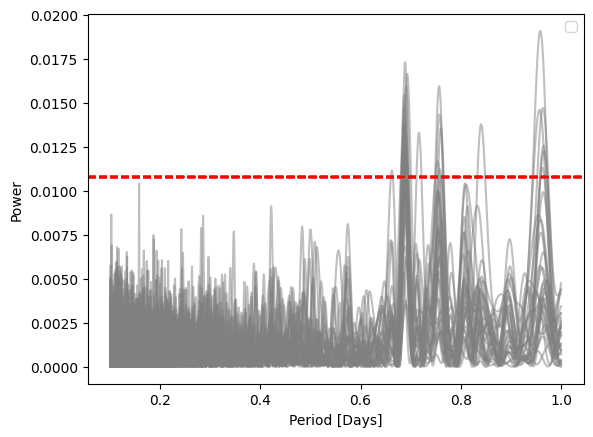

100%|██████████| 10000/10000 [17:22<00:00,  9.59it/s]


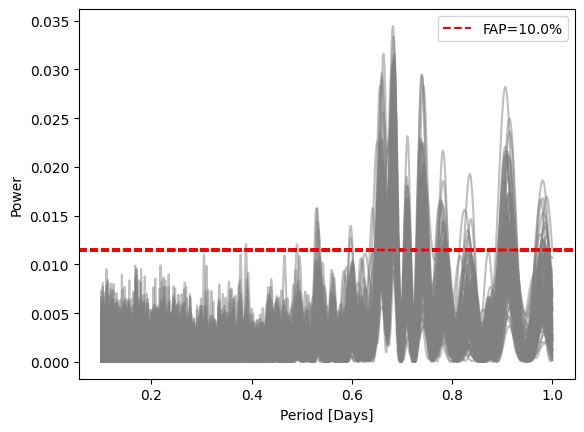

100%|██████████| 10000/10000 [17:20<00:00,  9.61it/s]
/home/ktp9/anaconda3/envs/TESSNeptune24/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


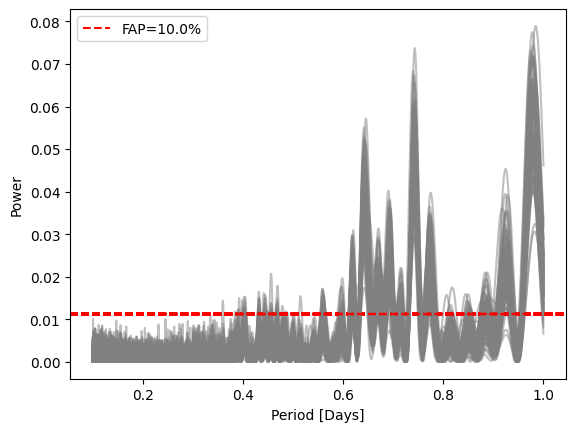

100%|██████████| 10000/10000 [17:22<00:00,  9.59it/s]


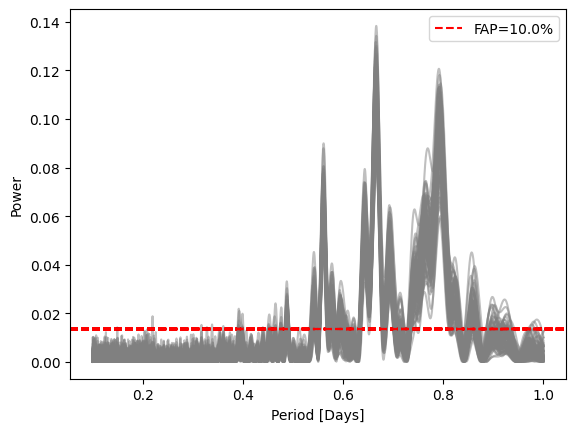

100%|██████████| 10000/10000 [19:16<00:00,  8.65it/s]


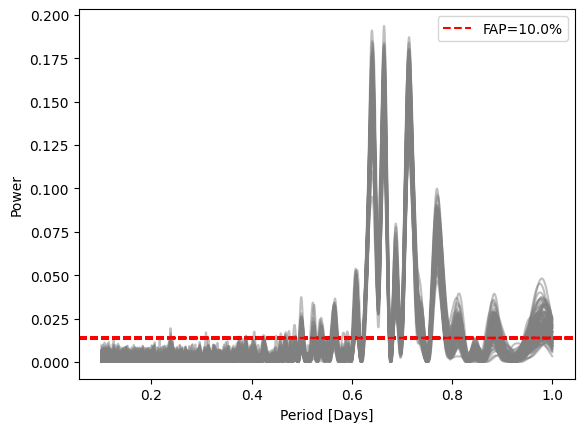

In [9]:
## now we bootstrap to get uncertainties on the peak frequencies (~100m)
from bootstrap import save_bootstrap
    
save_bootstrap(lc_list, [f"{sector}" for sector in planet_sectors], root + "bootstrap/")

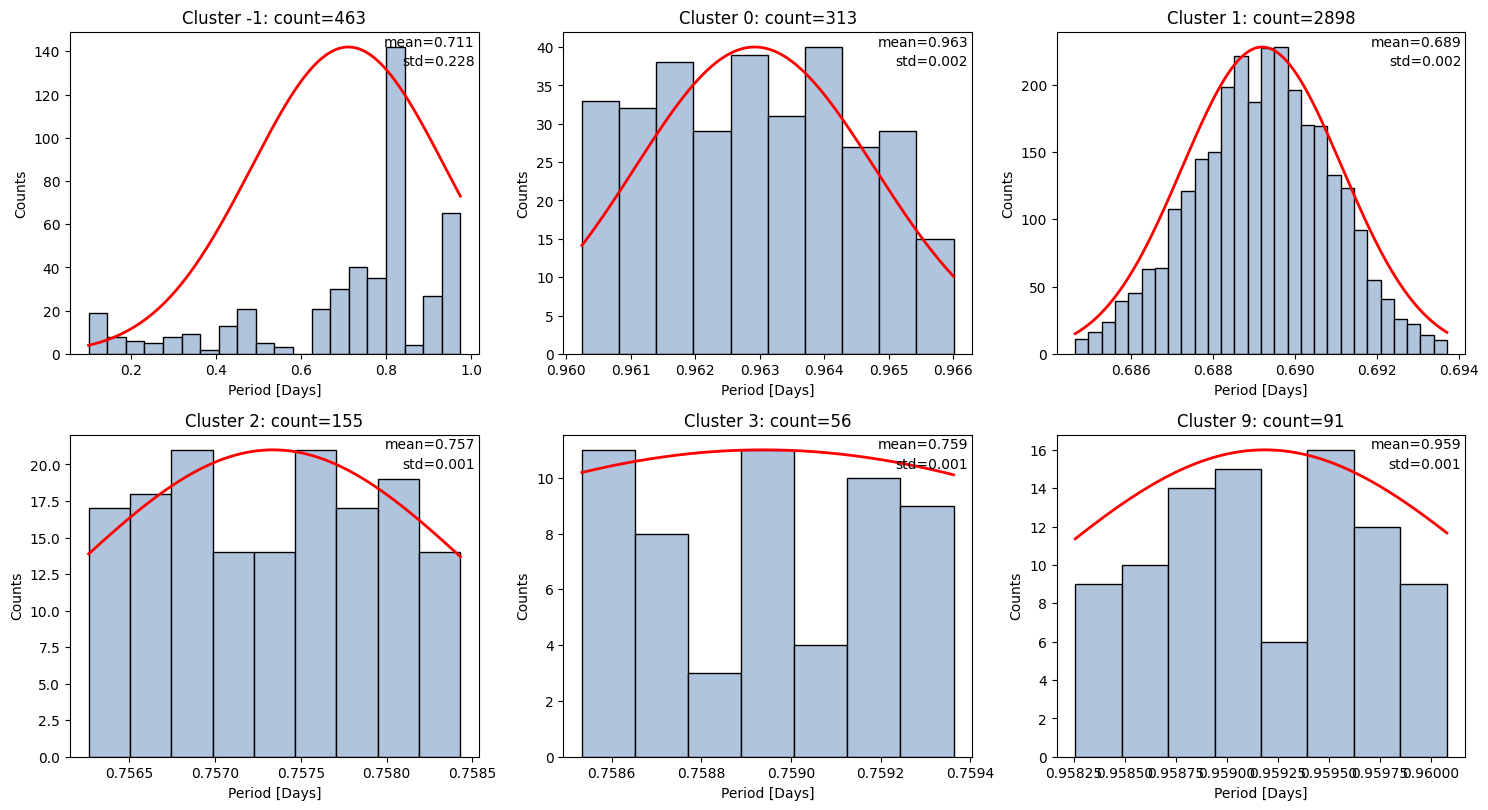

Sector: u42
0 out of 6 All means: [0.7108601283896014, 0.9629242711649775, 0.6891962636453663, 0.7573376175326223, 0.7589379918804927, 0.9591871978021455]
0 Peak periods from periodogram: []
matched means: []
matched stds: []



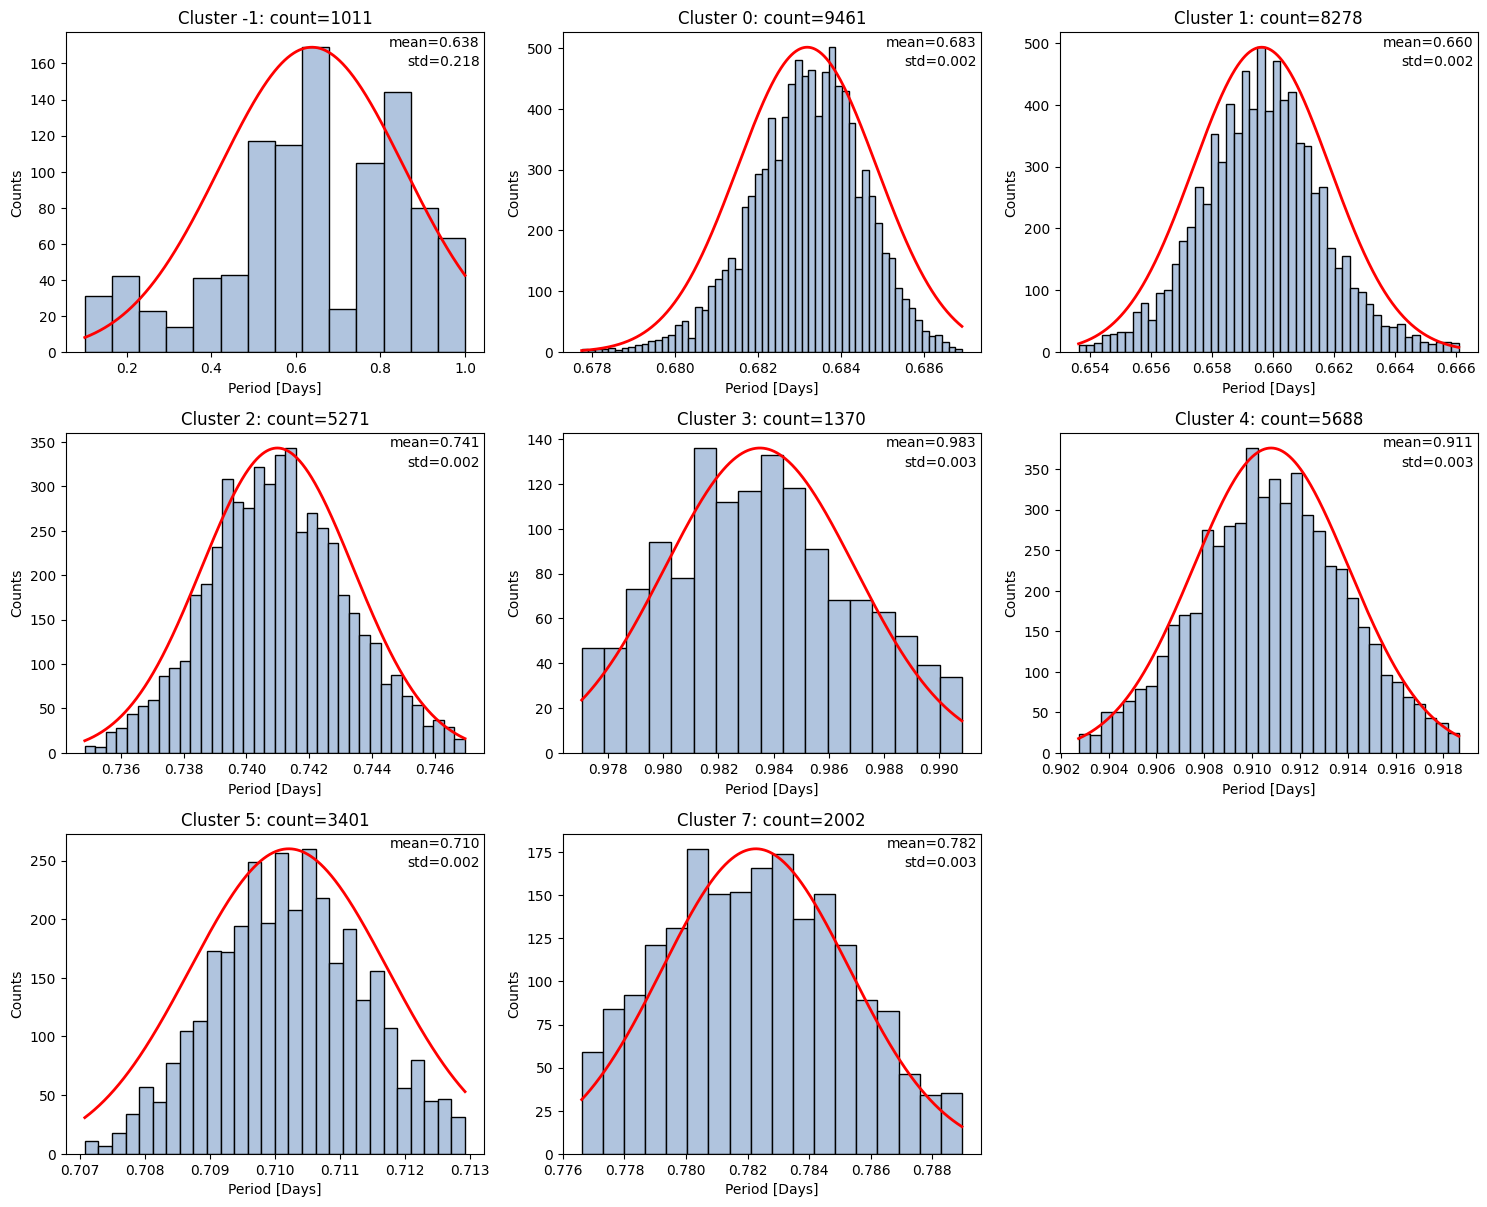

Sector: u43
5 out of 8 All means: [0.6379768088031743, 0.6831903631899505, 0.6596263618757588, 0.7409831948482112, 0.9834997981094681, 0.9107924157194106, 0.7102168043624191, 0.7822701705957731]
5 Peak periods from periodogram: [0.911494   0.74187201 0.7099102  0.68246785 0.65881956]
matched means: [0.68319036 0.65962636 0.74098319 0.91079242 0.7102168 ]
matched stds: [0.00167982 0.00223771 0.00241571 0.00325644 0.00152012]



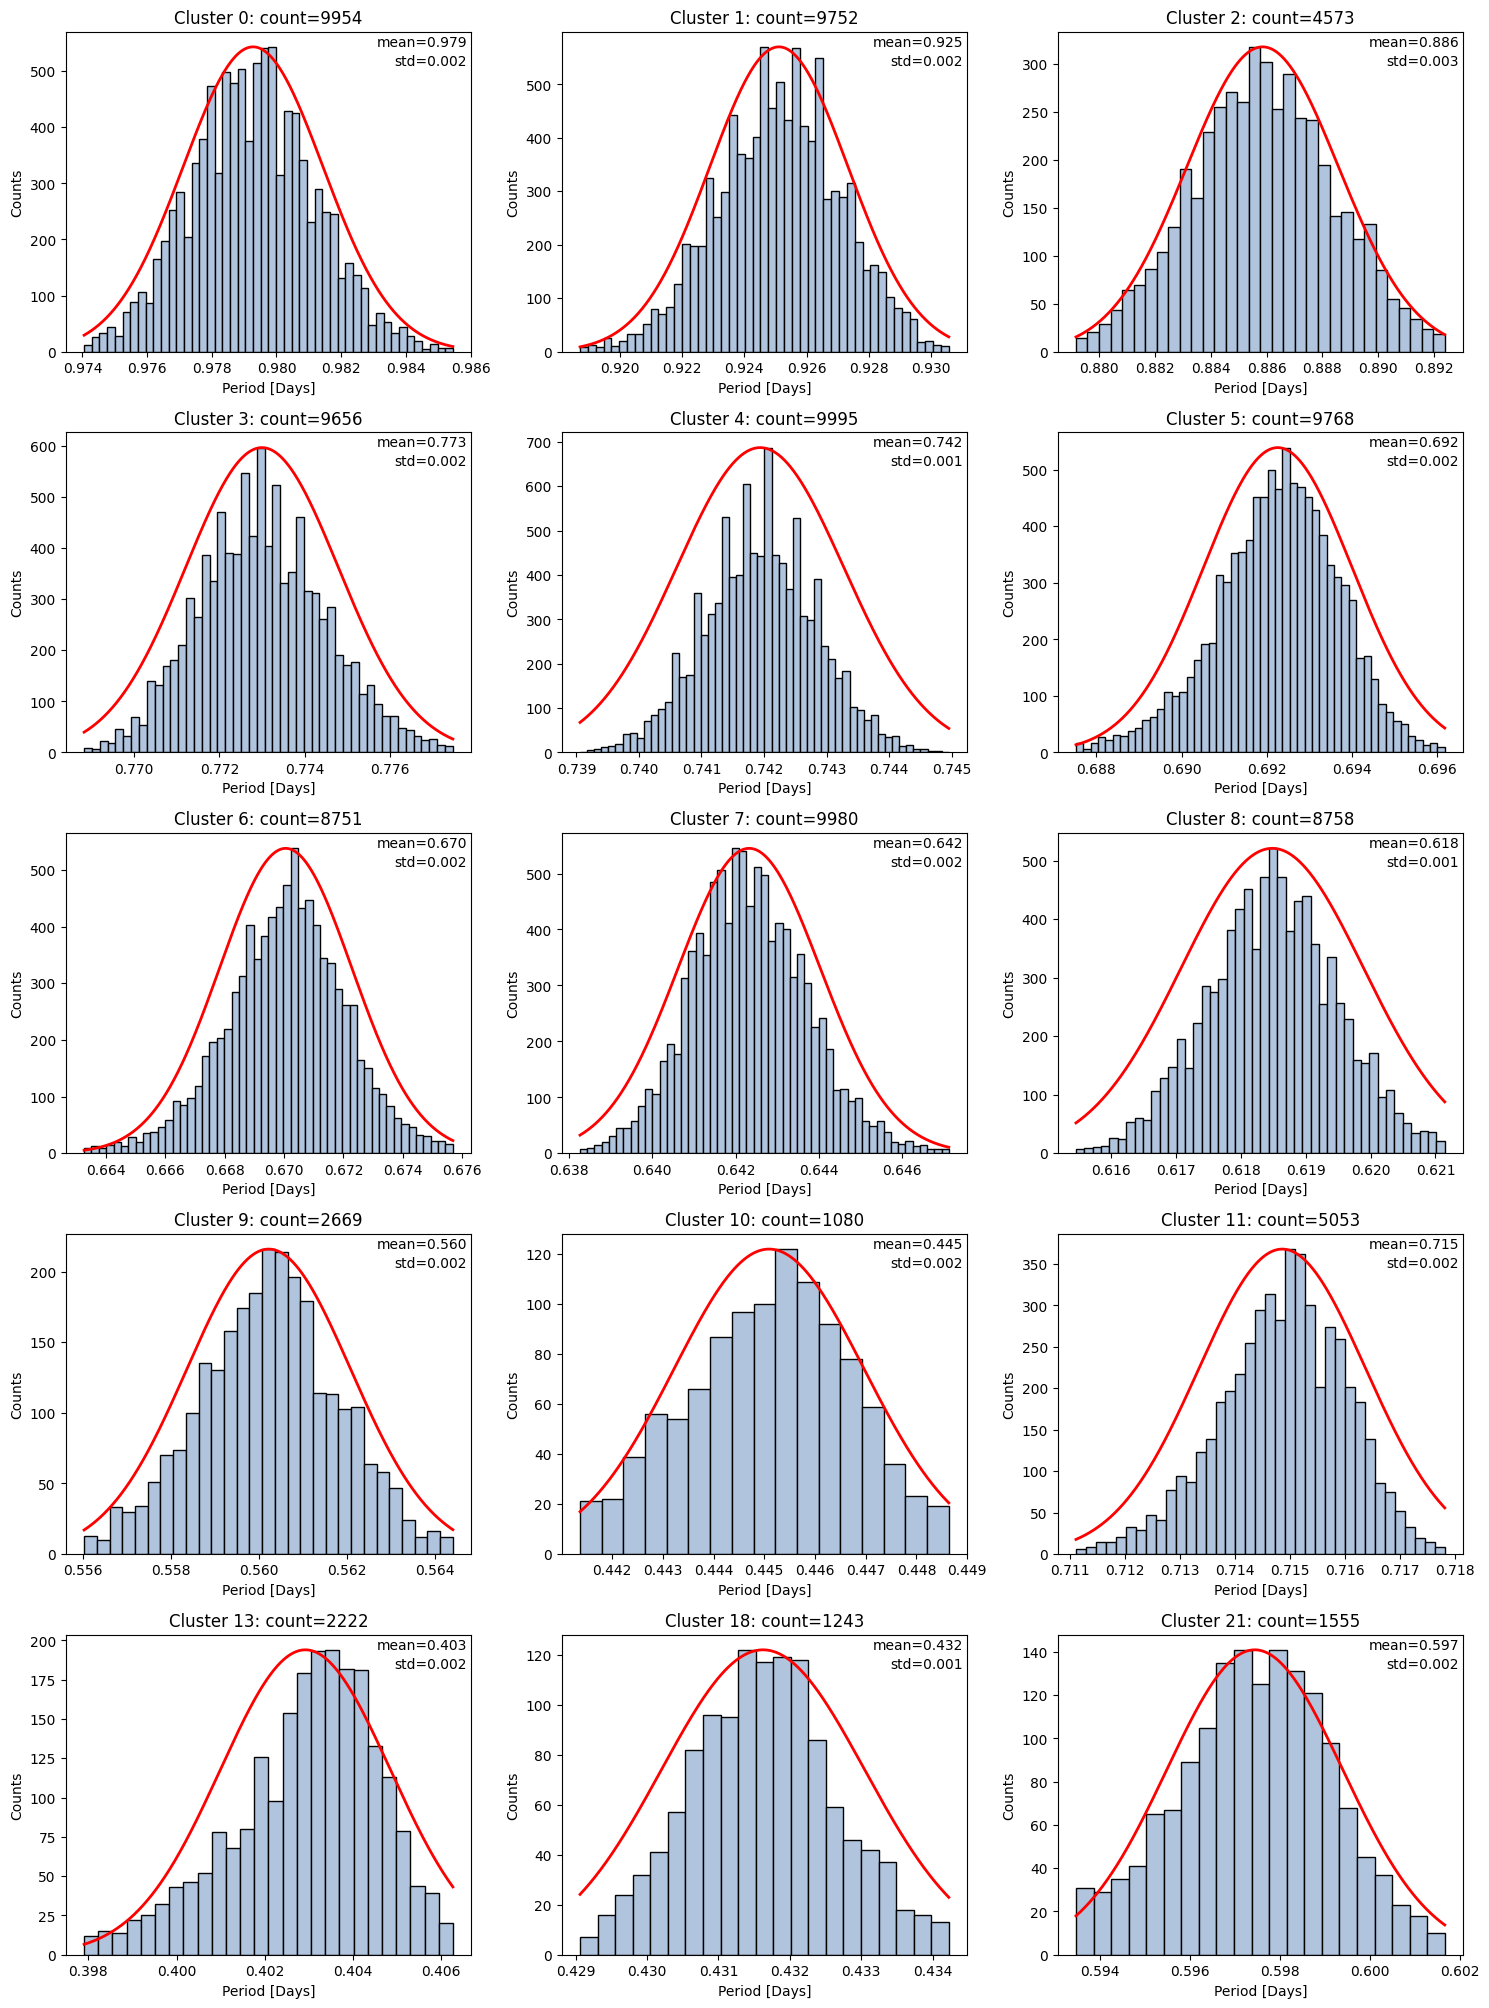

Sector: u44
11 out of 15 All means: [0.9792755297707513, 0.9251103125810293, 0.8858570030313364, 0.7729985563702119, 0.741938805708246, 0.6922566406597235, 0.6700561287158798, 0.642327393956414, 0.6184879363803957, 0.5602220855642656, 0.44509495755448975, 0.7148554335424523, 0.40292065613736183, 0.43162497209768247, 0.5974463242063326]
11 Peak periods from periodogram: [0.97979281 0.92379114 0.88662822 0.77347896 0.74267596 0.7142324
 0.69181307 0.67075836 0.64232409 0.61777271 0.5606293 ]
matched means: [0.97927553 0.92511031 0.885857   0.77299856 0.74193881 0.69225664
 0.67005613 0.64232739 0.61848794 0.56022209 0.71485543]
matched stds: [0.00216385 0.00222095 0.00271659 0.00179496 0.00133833 0.00174554
 0.00223268 0.0017072  0.00140674 0.00186226 0.00152081]



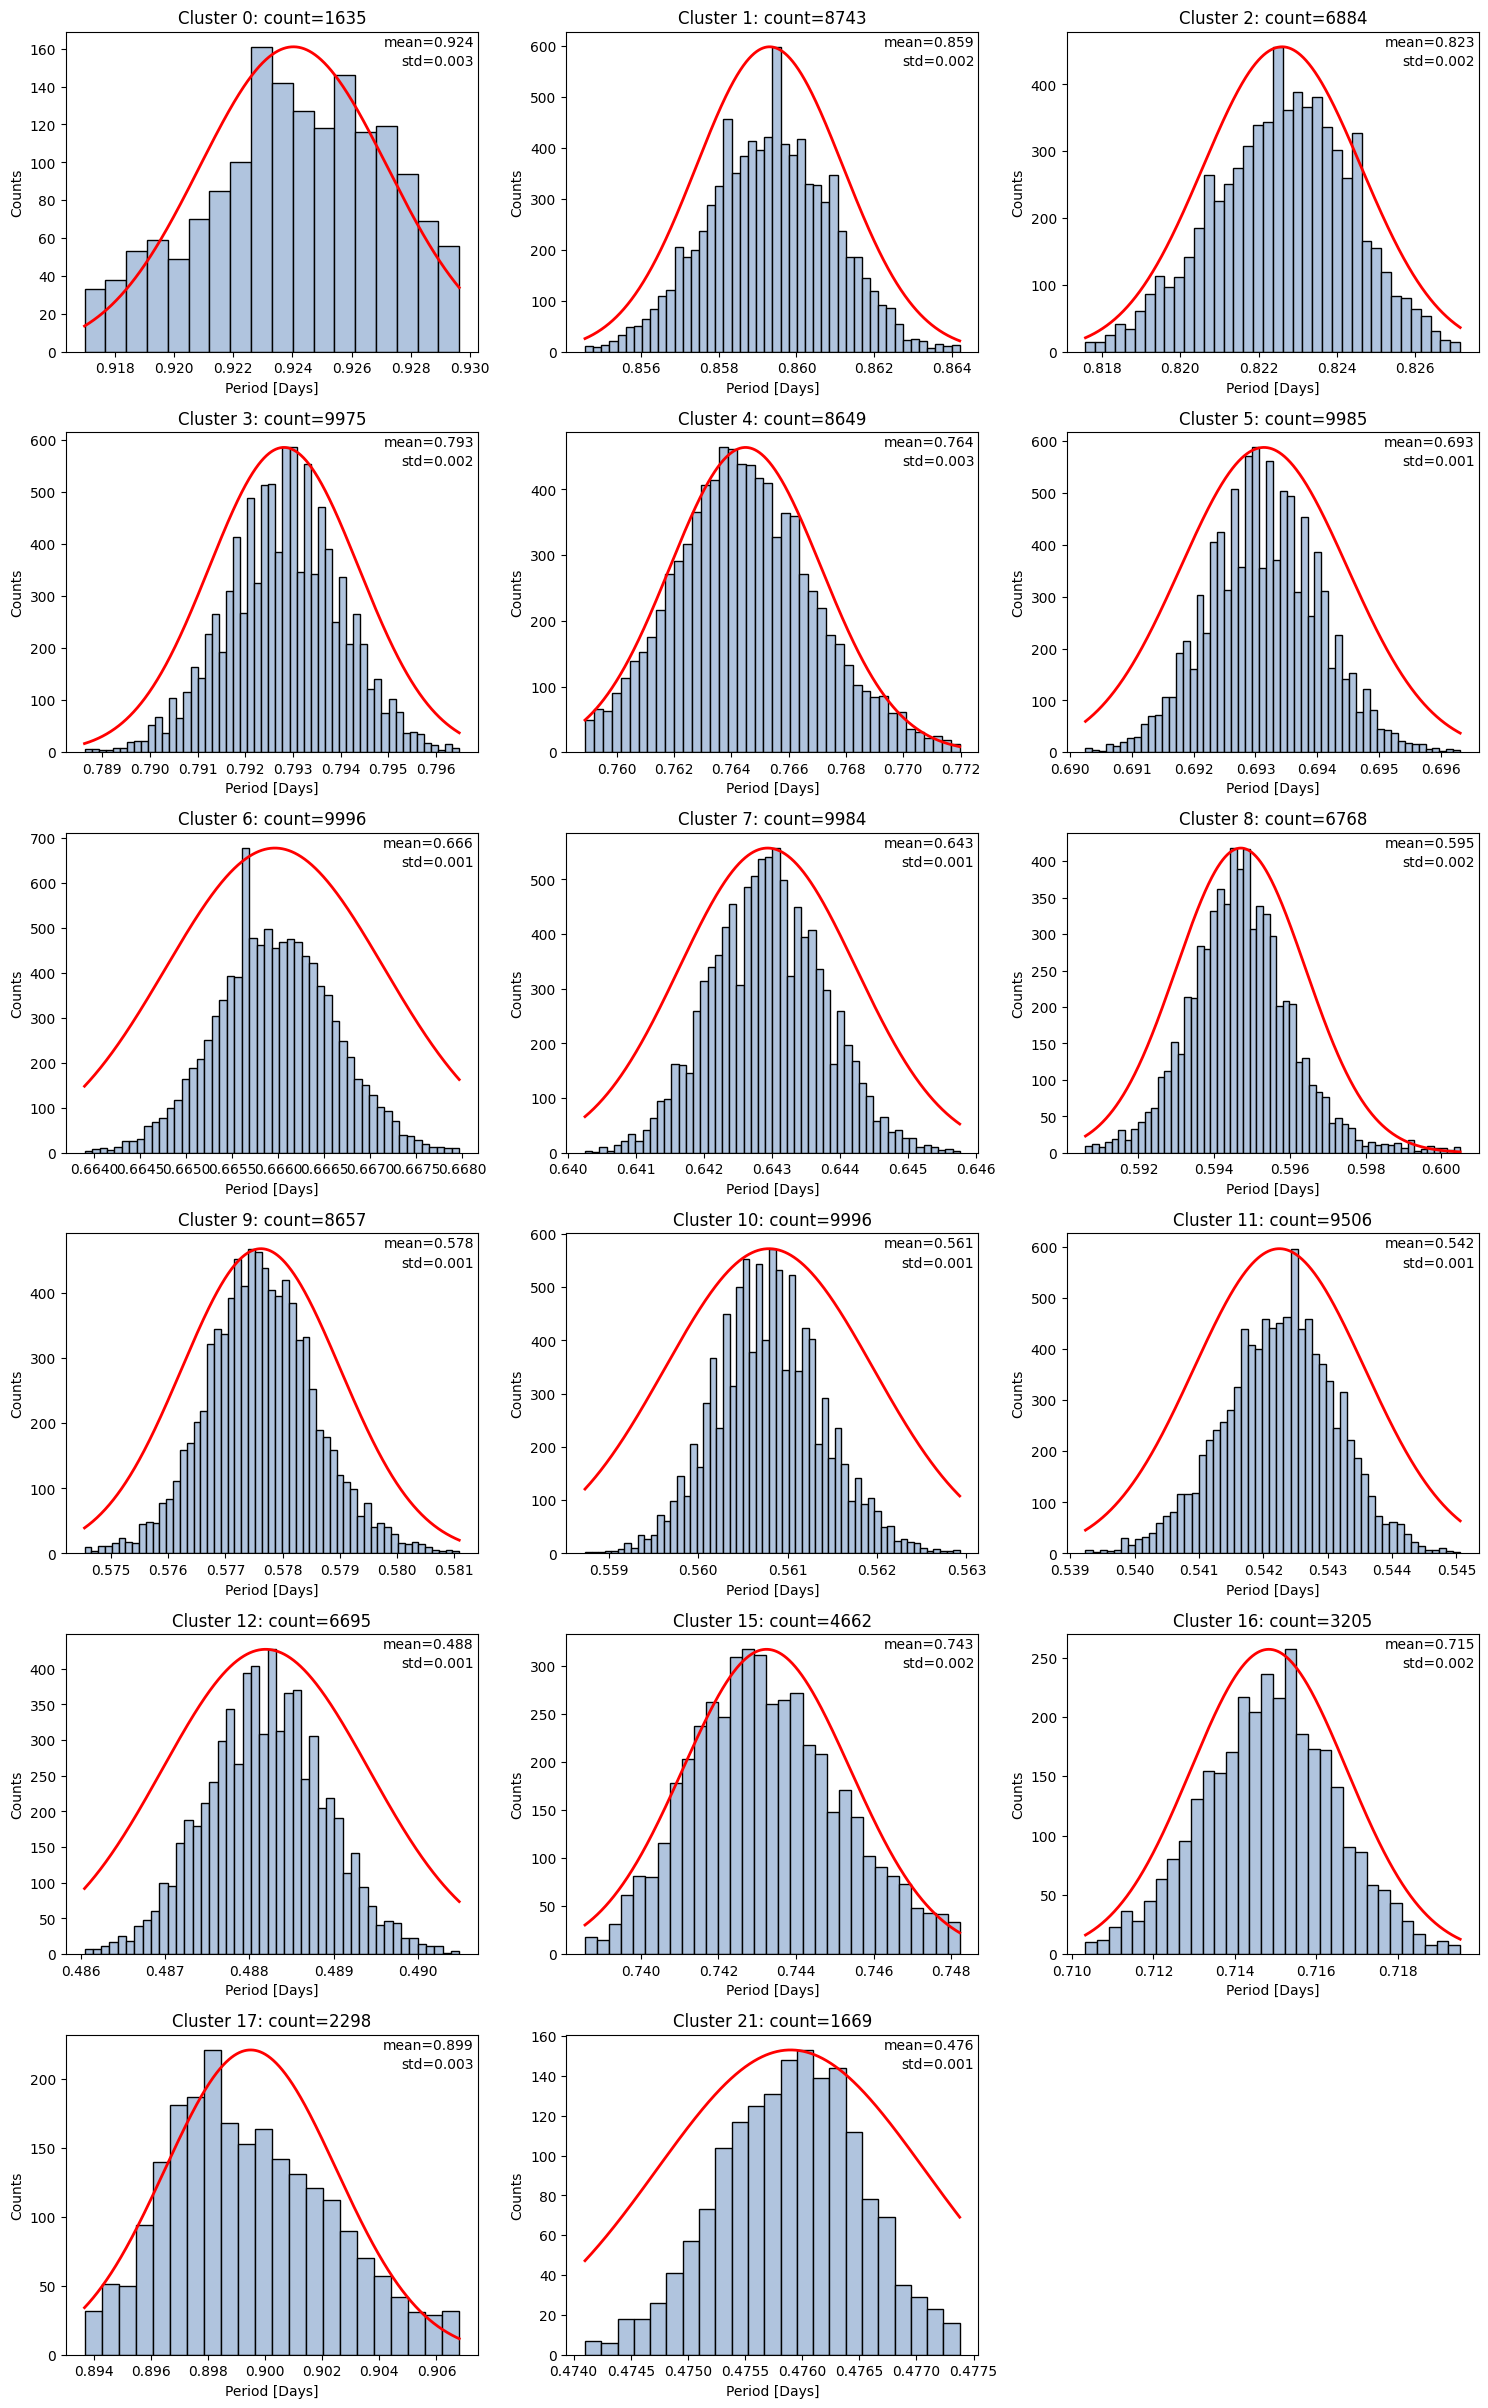

Sector: n42
14 out of 17 All means: [0.9240345222816174, 0.8593085328471907, 0.8226001381173376, 0.7928105139765356, 0.7644964250839441, 0.6931371808726575, 0.6659667229351237, 0.6429396461221943, 0.5947046518041049, 0.5776225406424935, 0.5607925260825928, 0.5422490408873931, 0.4881913084464969, 0.7432410653417774, 0.7148323007512529, 0.8994896457734055, 0.4758990764406261]
14 Peak periods from periodogram: [0.89999711 0.85865334 0.82094122 0.79411239 0.76414515 0.71469933
 0.69230085 0.66574627 0.64284977 0.59412428 0.57718931 0.56119301
 0.54240274 0.48794378]
matched means: [0.85930853 0.82260014 0.79281051 0.76449643 0.69313718 0.66596672
 0.64293965 0.59470465 0.57762254 0.56079253 0.54224904 0.48819131
 0.7148323  0.89948965]
matched stds: [0.00188993 0.0020155  0.00156662 0.00264036 0.00134742 0.00118609
 0.00130008 0.00170367 0.00138487 0.00116699 0.00132808 0.00122402
 0.00191209 0.00301095]



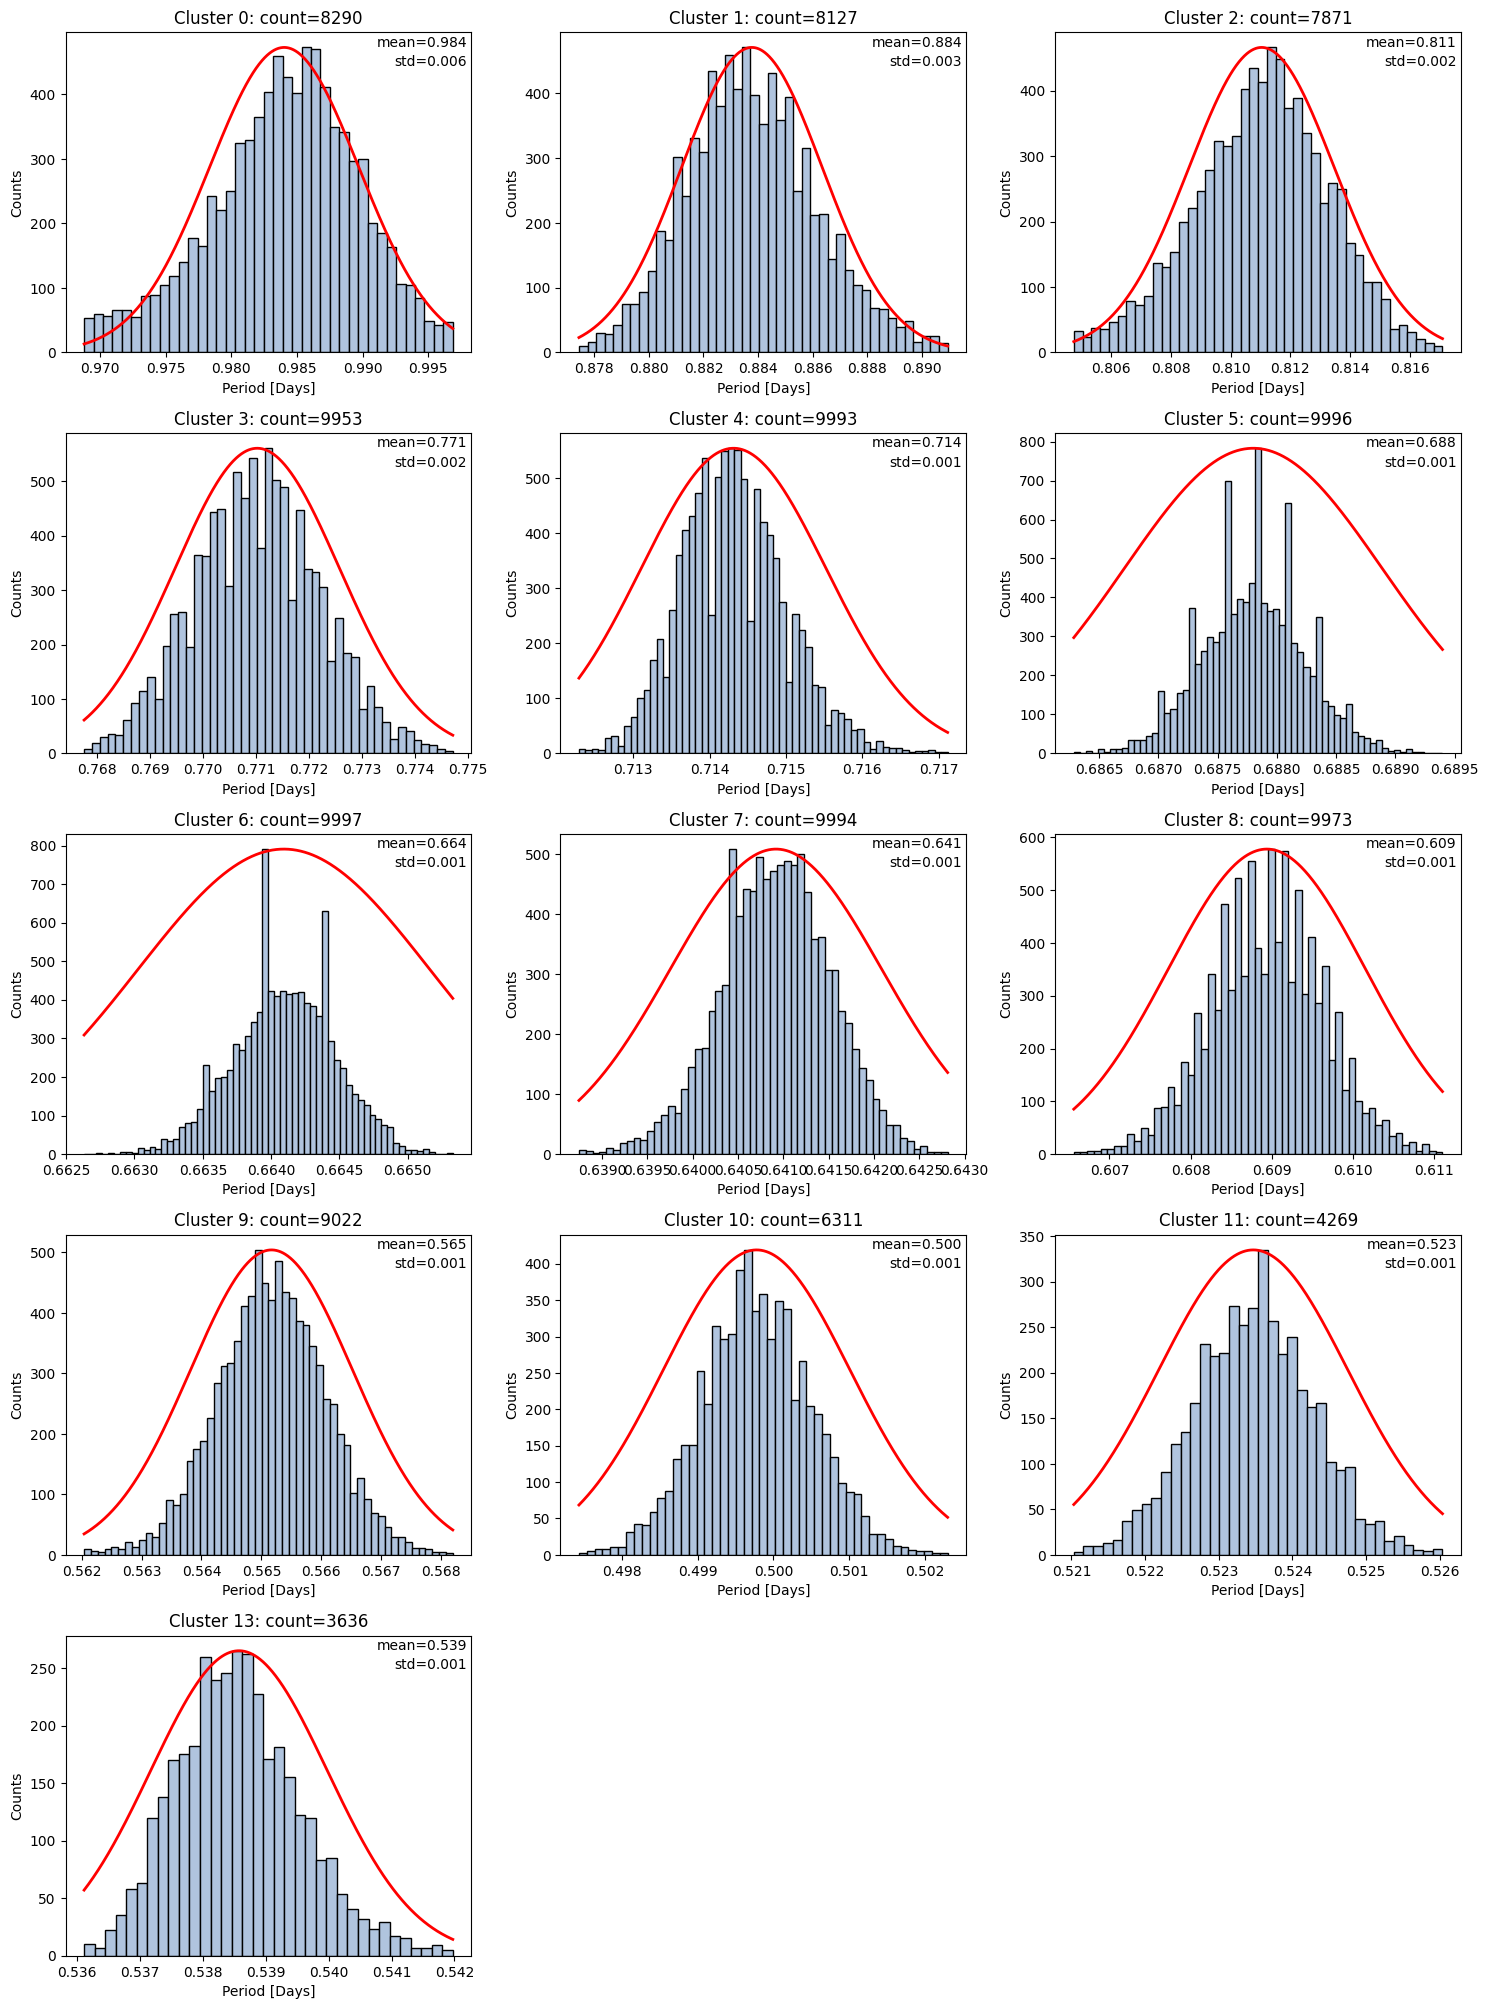

Sector: n70
13 out of 13 All means: [0.9840210204244897, 0.8837751165784482, 0.811038460187278, 0.7710267528289206, 0.7143138655123156, 0.6878009514550736, 0.6640933263465099, 0.6409191918873635, 0.6089377603681089, 0.565168322188379, 0.4997770223218318, 0.5234691280629102, 0.5385767588440071]
13 Peak periods from periodogram: [0.98452932 0.88217097 0.81183445 0.77008273 0.71392806 0.68695493
 0.66367158 0.64030014 0.60963103 0.56497969 0.53867674 0.52317697
 0.49956204]
matched means: [0.98402102 0.88377512 0.81103846 0.77102675 0.71431387 0.68780095
 0.66409333 0.64091919 0.60893776 0.56516832 0.49977702 0.52346913
 0.53857676]
matched stds: [0.00568674 0.00257752 0.00243698 0.00155174 0.00120943 0.00108635
 0.00106601 0.00116521 0.00121401 0.00135133 0.00123569 0.00128444
 0.00140393]



In [11]:
# now, cluster the bootstrapped periodograms with dbscan (30s)
from bootstrap import save_cluster

periodogram_list = []
bootstrap_list = []
for sector in planet_sectors:
    periodogram_list.append(np.load(root + "periodograms/" + f"{sector}_periodogram.npz"))
    bootstrap_list.append(np.load(root + "bootstrap/" + f"{sector}_bootstrap.npz")["peak_periods"])

save_cluster(periodogram_list, 
             bootstrap_list, 
             [f"{sector}" for sector in planet_sectors], 
             root + "clusters/",
             eps=0.0001, 
             ncols=3, 
             plot=True)

In [10]:
# next lets import in some wind equations to interpret the frequencies we found
from wind_equations import *

ur_wind_eqns = [sromovsky2012_odd_N, sromovsky2012_odd_S, sromovsky2015_N, sromovsky2015_S]
ur_wind_eqn_errs = [sigma_sromovsky2012_odd_N, sigma_sromovsky2012_odd_S, sigma_sromovsky2015_N, sigma_sromovsky2015_S]
ur_wind_eqn_strings = ["sromovsky2012_odd_N", "sromovsky2012_odd_S", "sromovsky2015_N", "sromovsky2015_S"]

nep_wind_eqns = [sromovsky1993_four, sromovsky1993_six, tollefson2013_kp, tollefson2014_kp]
nep_wind_eqn_errs = [sromovsky1993_four_err, sromovsky1993_six_err, tollefson2013_kp_err, tollefson2014_kp_err]
nep_wind_eqn_strings = ["sromovsky1993_four", "sromovsky1993_six", "tollefson2013_kp", "tollefson2014_kp"]

# planet data
uRe = 25559 * 1000
uRp = 24973 * 1000
uP = 17.247864
uRe_err = 4000
uRp_err = 20000
uP_err = 0.00001

nRe = 24764 * 1000
nRp = 24341 * 1000
nP = 15.9663
nRe_err = 15000
nRp_err = 30000
nP_err = 0.0002


In [3]:
from mcmc import run_mcmc

f_obs = 1.6
f_err = 0.1
model_eqn = nep_wind_eqns[0]  # choose a wind equation to test
sigma_eqn = sigma(nRe, nRp, nP, nRe_err, nRp_err, nP_err, nep_wind_eqn_errs[0])
freq_eqn = RHS(nRe, nRp, nP)  # string for plotting
sampler = run_mcmc(f_obs, f_err, model_eqn, sigma_eqn, freq_eqn, n_walkers=32, n_steps=5000)

samples = sampler.get_chain(discard=1000, flat=True)
phi_samples = samples[:, 0]

# Convert to degrees 
phi_deg = np.array(np.degrees(phi_samples))

100%|██████████| 5000/5000 [00:46<00:00, 107.68it/s]


(array([2.97895427e-04, 3.01031168e-04, 3.01031168e-04, 4.26460821e-04,
        4.48411011e-04, 4.17053597e-04, 5.92655112e-04, 7.52577920e-04,
        7.68256627e-04, 1.17276726e-03, 1.62744975e-03, 2.04763909e-03,
        2.88801777e-03, 3.68449607e-03, 5.59102680e-03, 8.13724876e-03,
        1.13827410e-02, 1.49700291e-02, 2.15582217e-02, 2.90651864e-02,
        3.78139047e-02, 4.76475896e-02, 5.37967783e-02, 5.49162380e-02,
        4.67978037e-02, 3.27684969e-02, 1.60205025e-02, 4.34613749e-03,
        8.15292747e-04, 2.19501893e-05]),
 array([4.73098992e-02, 2.53874627e+00, 5.03018264e+00, 7.52161900e+00,
        1.00130554e+01, 1.25044917e+01, 1.49959281e+01, 1.74873645e+01,
        1.99788008e+01, 2.24702372e+01, 2.49616736e+01, 2.74531099e+01,
        2.99445463e+01, 3.24359827e+01, 3.49274191e+01, 3.74188554e+01,
        3.99102918e+01, 4.24017282e+01, 4.48931645e+01, 4.73846009e+01,
        4.98760373e+01, 5.23674736e+01, 5.48589100e+01, 5.73503464e+01,
        5.98417827e+01

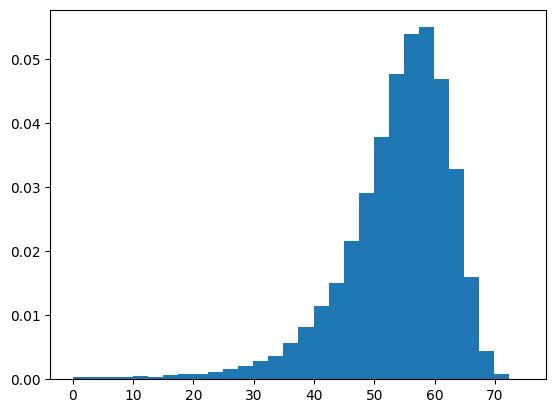

In [4]:
import matplotlib.pyplot as plt

plt.hist(phi_deg, bins=30, density=True)

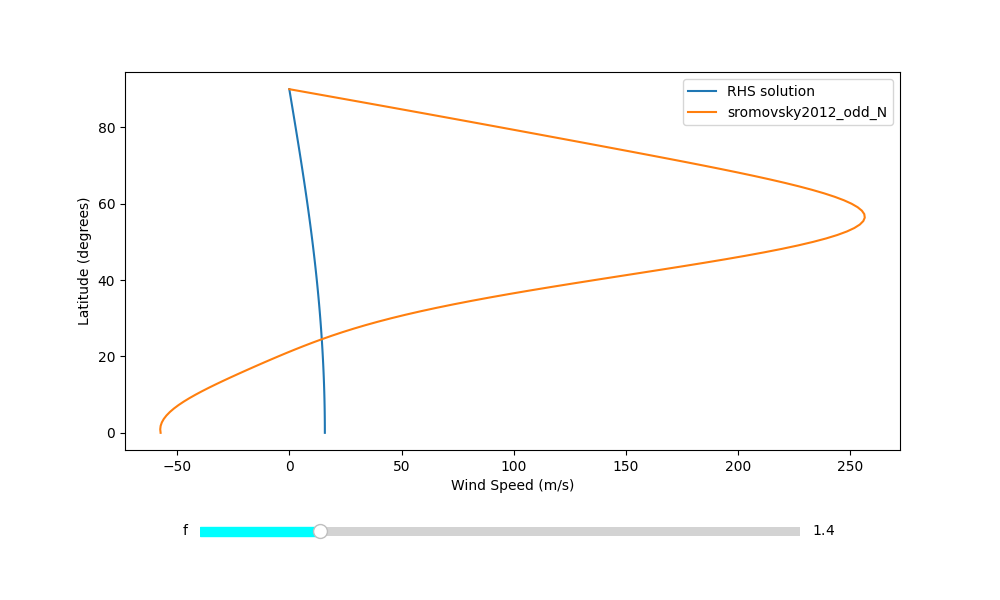

In [5]:
%matplotlib ipympl
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import numpy as np

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(bottom=0.25)  # Make room for slider

phi = np.linspace(0, np.pi/2, 100)
solution = RHS(uRe, uRp, uP)

# Initial plot
line1, = ax.plot(solution(phi, 1.4), phi*180/np.pi, label="RHS solution")
line2, = ax.plot(sromovsky2012_odd_N(phi), phi*180/np.pi, label="sromovsky2012_odd_N")
ax.set_xlabel("Wind Speed (m/s)")
ax.set_ylabel("Latitude (degrees)")
ax.legend()

# Create slider axis
ax_slider = plt.axes([0.2, 0.1, 0.6, 0.03])
slider = Slider(ax_slider, 'f', 1.3, 1.8, valinit=1.4, color='cyan')

# Update function
def update(val):
    f_val = slider.val
    line1.set_xdata(solution(phi, f_val))
    fig.canvas.draw_idle()

slider.on_changed(update)

plt.show()


In [ ]:
# run mcmc fits for each cluster and save the results (~115m)
from mcmc import save_mcmc 
# planet_sectors = ["u43"]
# load in the clusters
cluster_list = []
for sector in planet_sectors:
    cluster_list.append(np.load(root + "clusters/" + f"{sector}_clustered_peaks.npz", allow_pickle=True))

for i, cluster in enumerate(cluster_list):
    if planet_sectors[i][0] == "u":
        save_mcmc(ur_wind_eqns, ur_wind_eqn_errs, cluster, 
                  uRe, uRp, uP, uRe_err, uRp_err, uP_err, 
                  ur_wind_eqn_strings, f"{planet_sectors[i]}", root + "mcmc/")
    elif planet_sectors[i][0] == "n":
        save_mcmc(nep_wind_eqns, nep_wind_eqn_errs, cluster, 
                  nRe, nRp, nP, nRe_err, nRp_err, nP_err, 
                  nep_wind_eqn_strings, f"{planet_sectors[i]}", root + "mcmc/")

/home/ktp9/anaconda3/envs/TESSNeptune24/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2291: RuntimeWarning: invalid value encountered in scalar subtract
  p = (xf - fulc) * q - (xf - nfc) * r
/home/ktp9/anaconda3/envs/TESSNeptune24/lib/python3.11/site-packages/scipy/optimize/_optimize.py:2292: RuntimeWarning: invalid value encountered in scalar subtract
  q = 2.0 * (q - r)


Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.369822
Minimum f with at least one intersection: 1.369822
Using minimum frequency of 1.3605305096908973 for wind equation sromovsky2012_odd_N
Processing wind equation: sromovsky2012_odd_N
Using minimum frequency of 1.3605305096908973 for wind equation sromovsky2012_odd_S
Processing wind equation: sromovsky2012_odd_S
Using minimum frequency of 1.369822244200759 for wind equation sromovsky2015_N
Processing wind equation: sromovsky2015_N
Using minimum frequency of 1.369822244200759 for wind equation sromovsky2015_S
Processing wind equation: sromovsky2015_S
Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.360531
Minimum f with at least one intersection: 1.369822
Minimum f with at least one intersection: 1.369822
Using minimum frequency of 1.3605305096908973 for wind equation sromovsky2012_odd_N
Proces

  4%|▍         | 208/5000 [00:03<01:16, 62.53it/s]

100%|██████████| 5000/5000 [01:22<00:00, 60.75it/s]


Median latitude (deg): 37.270036841305895
Frequency, error: 1.5160097561236505 0.005142894202874619


...

Median latitude (deg): 78.61524494652231
Frequency, error: 1.910332331727919 0.004687410570798787


100%|██████████| 5000/5000 [00:46<00:00, 107.95it/s]


Median latitude (deg): 76.55150415158946
Frequency, error: 1.8567455494113496 0.00484006267200728


100%|██████████| 5000/5000 [00:46<00:00, 108.33it/s]


Median latitude (deg): 75.32921881168711


In [13]:
# load the mcmc posteriors back in
mcmc_dir = root + "mcmc/"

mcmc_list = []
for sector in planet_sectors:
    mcmc_list.append(np.load(mcmc_dir + f"{sector}_phi_distributions.npz", allow_pickle=True))

n_eqns, n_solutions, n_samples
(4, 3, 128000)


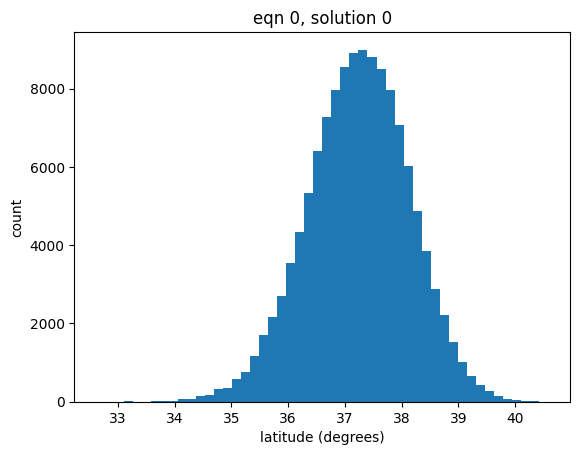

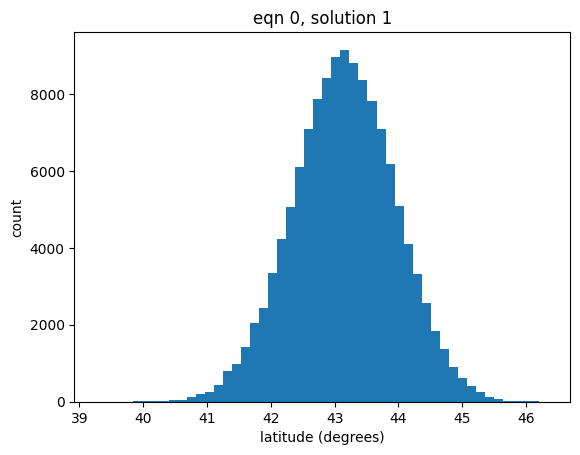

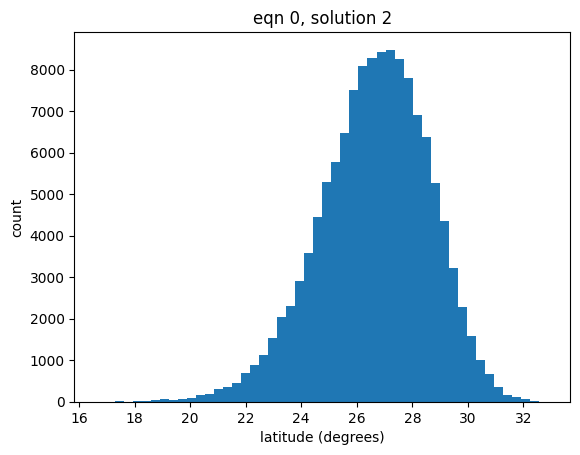

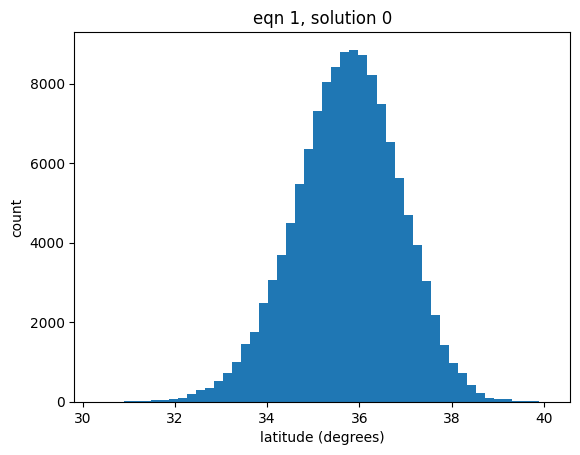

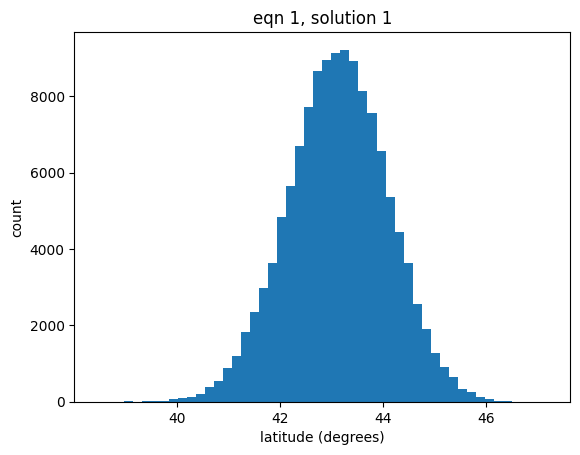

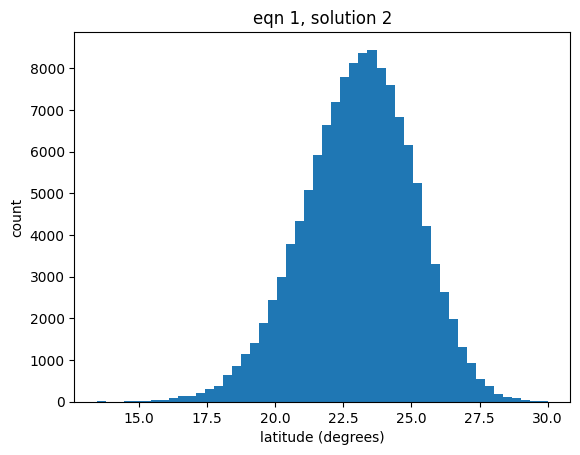

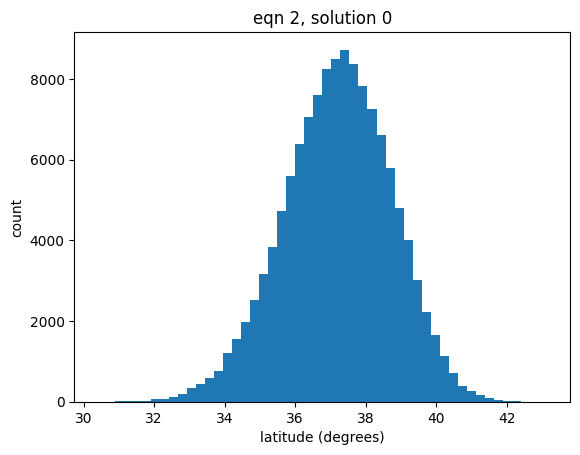

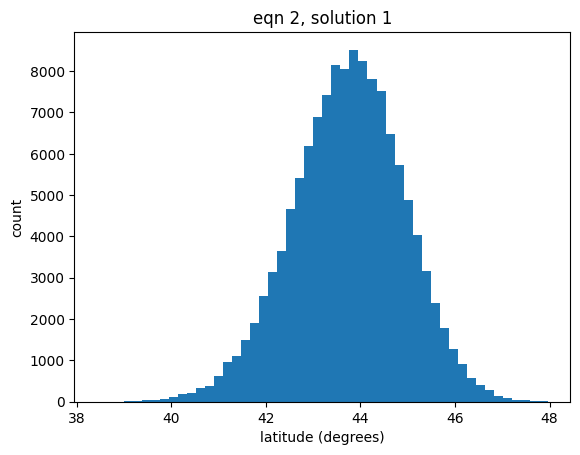

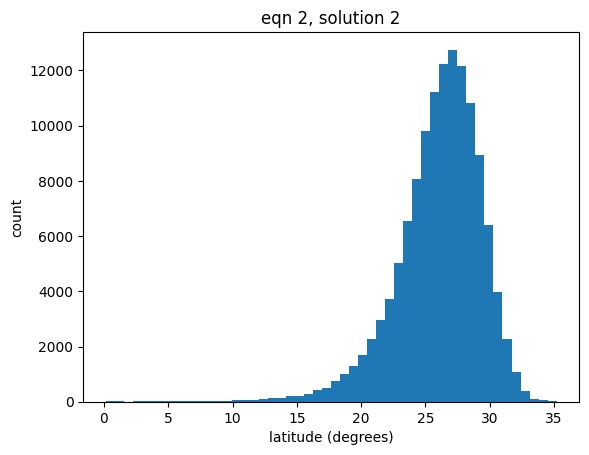

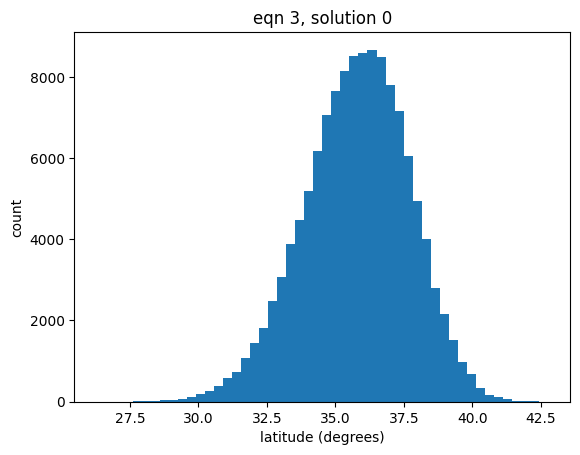

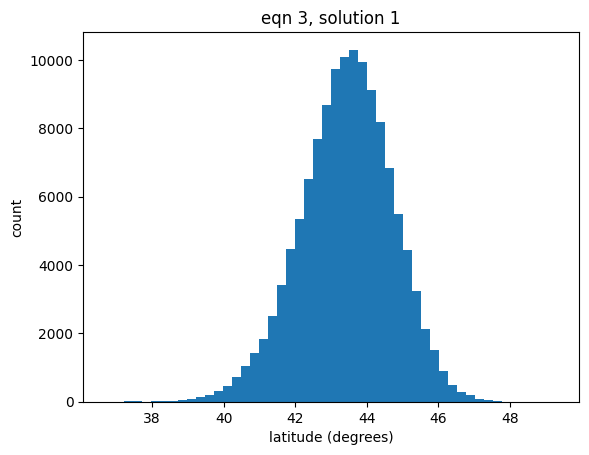

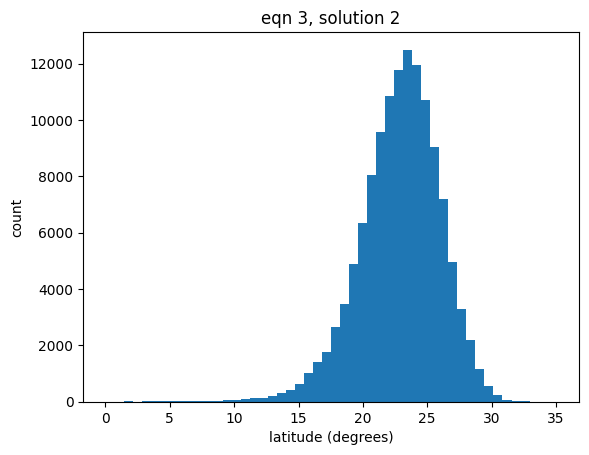

In [7]:
import matplotlib.pyplot as plt

u43_phi_dist = mcmc_list[1]["phi_distributions"]
print("n_eqns, n_solutions, n_samples")
print(u43_phi_dist.shape)

for i in range(u43_phi_dist.shape[0]):
    for j in range(u43_phi_dist.shape[1]):
        plt.figure()
        plt.hist(u43_phi_dist[i, j, :], bins=50)
        plt.title(f"eqn {i}, solution {j}")
        plt.xlabel("latitude (degrees)")
        plt.ylabel("count")
        plt.show()

# from mcmc import fit_all_distributions

# all_means, all_stds = fit_all_distributions(u43_phi_dist, ur_wind_eqn_strings, verbose=True)


In [14]:
# we now have posterior distributions for each solution, lets get one sigma interval
from mcmc import fit_all_distributions

for i, phi_dist in enumerate(mcmc_list):
# phi_dist = mcmc_list[1]

    all_latitudes, all_standard_devs = fit_all_distributions(phi_dist["phi_distributions"], phi_dist["wind_eqn_strings"])
    print(f"Planet sector: {planet_sectors[i]}")
    print(len(all_latitudes))
    print(all_latitudes)
    print("stds")
    print(len(all_standard_devs))

    print(all_standard_devs)
    np.savez(root + "latitudes/" + f"{planet_sectors[i]}_latitude_solutions.npz", 
                lat=np.array(all_latitudes, dtype=object), std=np.array(all_standard_devs, dtype=object), allow_pickle=True)

Processing Wind Equation: sromovsky2012_odd_N
Processing Wind Equation: sromovsky2012_odd_S
Processing Wind Equation: sromovsky2015_N
Processing Wind Equation: sromovsky2015_S
& Eqn 1 & Eqn 2 & Eqn 3 & Eqn 4
Planet sector: u42
4
[[], [], [], []]
stds
4
[[], [], [], []]
Processing Wind Equation: sromovsky2012_odd_N
Skewness: -0.170, Mean: 37.245, Std: 0.900, Mu0: 37.245, Sigma0: 0.900, Mu1: 37.245, Sigma1: 0.900
Skewness: -0.063, Mean: 43.168, Std: 0.797, Mu0: 43.168, Sigma0: 0.797, Mu1: 43.168, Sigma1: 0.797
Skewness: -0.375, Mean: 26.620, Std: 2.003, Mu0: 26.620, Sigma0: 2.003, Mu1: 26.620, Sigma1: 2.003
Processing Wind Equation: sromovsky2012_odd_S
Skewness: -0.151, Mean: 35.710, Std: 1.146, Mu0: 35.710, Sigma0: 1.146, Mu1: 35.710, Sigma1: 1.146
Skewness: -0.114, Mean: 43.156, Std: 0.979, Mu0: 43.156, Sigma0: 0.979, Mu1: 43.156, Sigma1: 0.979
Skewness: -0.222, Mean: 23.103, Std: 2.019, Mu0: 23.103, Sigma0: 2.019, Mu1: 23.103, Sigma1: 2.019
Processing Wind Equation: sromovsky2015_N
Sk